In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

In [2]:
import cv2
import bm3d
import torch
from fvcore.nn import FlopCountAnalysis, flop_count_table
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path
from skimage.restoration import estimate_sigma
from torch.utils.data import DataLoader
from torchvision.models.feature_extraction import create_feature_extractor, get_graph_node_names

from admmtor.eprocessing.dataload import ImageDataset
from admmtor.inference.patch_merge_inference import PatchMergeInference
from admmtor.modelbuild.ffdnet import FFDNet
from admmtor.modelbuild.dncnn import DnCNN
from admmtor.modelbuild.denoiser import DivergentRestorer
from admmtor.modelbuild.nafnet import NAFNet
from admmtor.modelbuild.dranet import DRANet
from admmtor.modelbuild.restormer import Restormer
from admmtor.modelbuild.swinir import SwinIR
from admmtor.eprocessing.etransforms import Scale, RandCrop, AddAWGN

c:\ProgramData\miniconda3\envs\admmtor\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\ProgramData\miniconda3\envs\admmtor\Lib\site-packages\timm\models\layers\__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [3]:
sns.set(style="whitegrid")

In [4]:
from prettytable import PrettyTable

def get_model_params(model):
    table = PrettyTable(["Modules", "Parameters"])
    total_params = 0
    for name, parameter in model.named_parameters():
        if not parameter.requires_grad:
            continue
        try:
            params = parameter.numel()
            table.add_row([name, params])
            total_params += params
        except Exception as e:
            print(f"Error processing parameter {name}: {e}")
    print(table)
    print(f"Total Trainable Params: {total_params}")
    return total_params

In [5]:
def average_psnr(mse_values, max_pixel_value=1.0):
    psnr_values = []
    for mse in mse_values:
        if mse == 0:
            psnr = float('inf')  # Infinite PSNR for zero MSE
        else:
            psnr = 10 * np.log10((max_pixel_value ** 2) / np.mean(mse))
        psnr_values.append(psnr)
    
    return np.mean(psnr_values)


In [6]:
def get_flop_count(model, device='cuda'):
    dummy_input = torch.randn(1, 3, 224, 224).to(device)  # Adjust the shape according to your model's input
    flops = FlopCountAnalysis(model, dummy_input)
    return f"{flops.total() / 1e9:.2f} GFLOPs"

# Analyze ADMM-TV layer outputs

In [7]:
DECONV1 = {'kern_size': (),
         'max_iters': 100,
         'iso': True}
DECONV2 = {'kern_size': (),
         'max_iters': 100,
         'iso': True}

device = 'cuda'
modelp = Path('D:/Projects/torch-admm-deconv/trained_models/2026/blind/admm/admm-bsd-div2k-15and35std-june-128-cwa-modif-2_epoch04_vloss0.1031.tar')
# FROZE = DivergentRestorer(3, 2, 3,
#                           3, 4, 86,
#                           86, 8,
#                           output_activation=torch.nn.Sigmoid(), admms=[DECONV1, DECONV2])
ADMM = DivergentRestorer([2, 8, 32], 3,
                              3, 86,
                              86, 8,
                              output_activation=torch.nn.Sigmoid(), admms=[DECONV1, DECONV2])
model_d = torch.load(modelp, weights_only=False)
ADMM.load_state_dict(model_d['model_state_dict'])
ADMM = ADMM.to(device)
ADMM = ADMM.eval()

In [8]:
feature_extractor = create_feature_extractor(ADMM, return_nodes=['blocks.0.admms.0', 'blocks.0.admms.1'])

In [9]:
min_std, max_std = 25, 26
xp = Path(r'D:\\Projects\\datasets\\denoising_test_sets\\CBSD68')
yp = xp

In [10]:
imd = ImageDataset(xp, yp, transforms=[Scale(), AddAWGN(std_range=(min_std, max_std), both=False)])
im_loader = torch.utils.data.DataLoader(imd, shuffle=False, batch_size=1)

In [11]:
x_test, y_test = next(iter(im_loader))
features = feature_extractor(x_test.to(device))
feat_admm0 = features['blocks.0.admms.0']
feat_admm1 = features['blocks.0.admms.1']

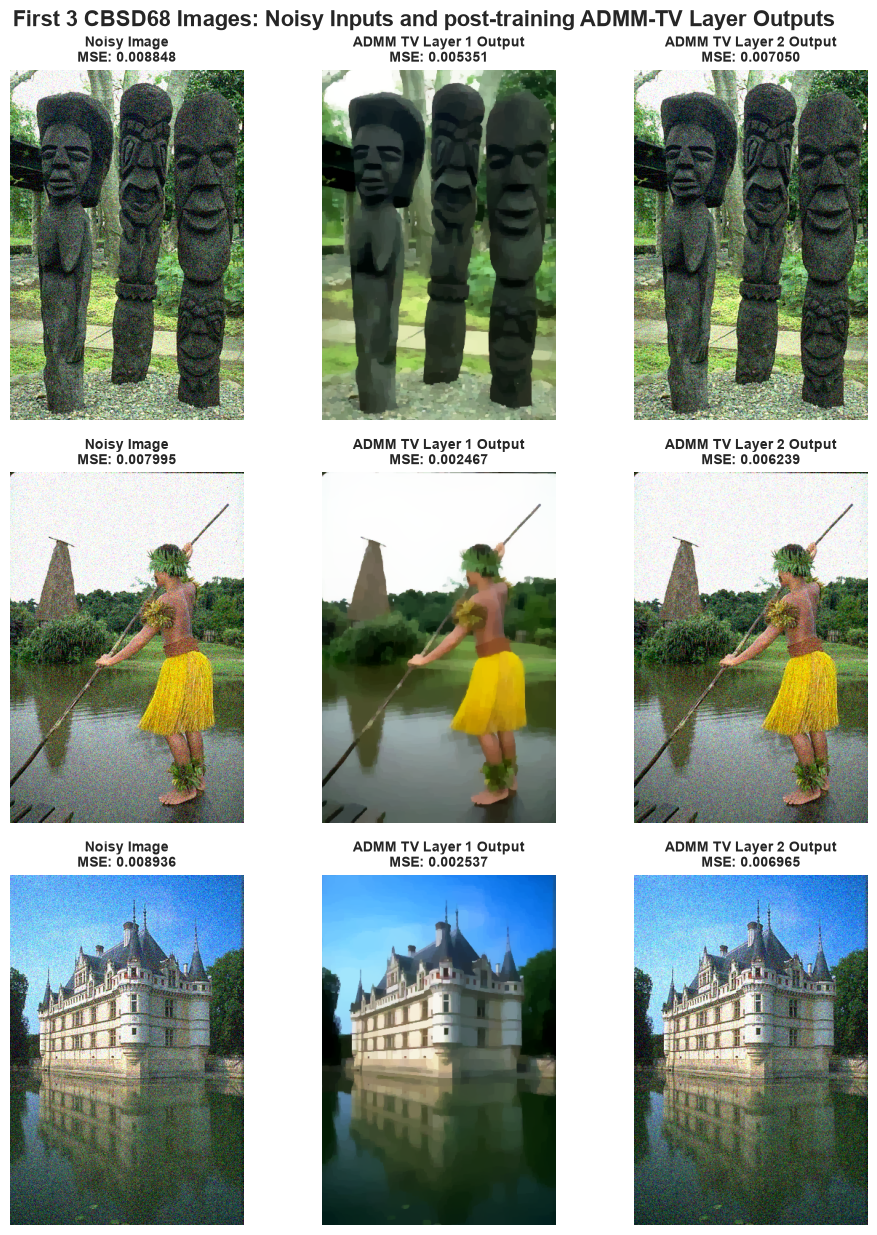

In [53]:
# Plot the first 3 CBSD68 images and their ADMM-TV outputs in one figure
fig, axes = plt.subplots(3, 3, figsize=(12, 15), gridspec_kw={"wspace": 0.02, "hspace": 0.15})

for row, (noisy_img, clean_img, name) in enumerate(dataset_pairs[:3]):
	noisy_img = np.asarray(noisy_img, dtype=np.float32)
	clean_img = np.asarray(clean_img, dtype=np.float32)

	with torch.no_grad():
		noisy_t = torch.from_numpy(noisy_img).permute(2, 0, 1).unsqueeze(0).to(device)
		features = feature_extractor(noisy_t)
		layer1_img = features["blocks.0.admms.0"][0].cpu().numpy().transpose(1, 2, 0)
		layer2_img = features["blocks.0.admms.1"][0].cpu().numpy().transpose(1, 2, 0)

	plots = [
		(noisy_img, "Noisy Image"),
		(layer1_img, "ADMM TV Layer 1 Output"),
		(layer2_img, "ADMM TV Layer 2 Output"),
	]

	for ax, (img, title) in zip(axes[row], plots):
		mse = np.mean((img - clean_img) ** 2)
		ax.imshow(normalize_for_display(img))
		ax.set_title(f"{title}\nMSE: {mse:.6f}", fontsize=10, fontweight="bold")
		ax.axis("off")

	axes[row, 0].set_ylabel(name, fontsize=13, fontweight="bold", rotation=90, labelpad=15)

fig.suptitle("First 3 CBSD68 Images: Noisy Inputs and post-training ADMM-TV Layer Outputs",
			 fontsize=16, fontweight="bold", y=0.92)

plt.savefig("admm_tv_layer_outputs_first_3_images.png", dpi=300,
			transparent=True, bbox_inches="tight", pad_inches=0)
plt.show()


In [ ]:
# Vizualize the rgb image
plt.figure(figsize=(10, 10))
plt.imshow(feat_admm1.detach().cpu().numpy()[0].transpose(1, 2, 0))

# Analyze test outcomes

## Prepare data

In [ ]:
dsets_p = 'D:/Projects/datasets/denoising_test_sets'
res_paths = [res_p for res_p in Path(dsets_p).glob('*std*')]

In [ ]:
models_names = ['bm3d', 'dncnn', 'ffdnet', 'restormer', 'dranet', 'restormer', 'swinir', 'nafnet', 'admm']

In [ ]:
res_paths_wmodels = [f'{path}/{model}/metrics_{model}.csv'.replace("\\", "/") for path in res_paths for model in models_names]

In [ ]:
res_paths_wmodels[23]

In [ ]:
results_dfs = []
for path in res_paths_wmodels:
    df = pd.read_csv(path)
    parts = path.split("/")
    model_name = parts[-1].split("_")[-1].strip('.csv')
    if model_name == 'winir':
        model_name = 'swinir'
    df["model_name"] = model_name
    std_val = parts[-3].split("_")[-2]
    df["std_val"] = std_val
    dset_name = parts[-3].split("_")[0]
    df["dset_name"] = dset_name 
    results_dfs.append(df)
all_dfs = pd.concat(results_dfs, axis=0).reset_index(drop=True)

In [ ]:
all_dfs['inverse_sam'] = 1 - all_dfs['sam']
all_dfs['inverse_dists'] = 1 - all_dfs['dists']
all_dfs['inverse_lpips'] = 1 - all_dfs['lpips']
all_dfs['inverse_blur_effect'] = 1 - all_dfs['blur_effect']

In [ ]:
metrics_n = [col for col in all_dfs.columns if col not in ['model_name', 'std_val', 'dset_name']]

In [ ]:
barplot_model_metrics_dict = {}
for model in models_names:
    barplot_model_metrics_dict[model] = []
    for metric in metrics_n:
        if metric == 'psnr':
            mse_values = all_dfs.loc[all_dfs['model_name'] == model, 'mse'].values
            barplot_model_metrics_dict[model].append(average_psnr(mse_values))
        else:
            barplot_model_metrics_dict[model].append(np.mean(all_dfs.loc[all_dfs['model_name'] == model, metric].values))
barplot_df = pd.DataFrame(barplot_model_metrics_dict, index=metrics_n).T

## Plot Stats

In [ ]:
def plot_grouped_metrics(df, metrics_subset=None, normalize=False, index_col=0):
    df = df.copy()
    df['Model'] = df.index.astype(str)
    
    if metrics_subset is not None:
        columns_to_keep = metrics_subset + ['Model']
        valid_columns = [col for col in columns_to_keep if col in df.columns]
        df = df[valid_columns]
        
    if normalize:
        metrics = df.columns.drop('Model')
        for col in metrics:
            min_val = df[col].min()
            max_val = df[col].max()
            if max_val != min_val:
                df[col] = (df[col] - min_val) / (max_val - min_val)
                
    df_melted = pd.melt(df, id_vars=['Model'], var_name='Metric', value_name='Score')
    
    plt.figure(figsize=(14, 6))
    palette = 'tab10' if (metrics_subset and len(metrics_subset) <= 10) else 'tab20'
    ax = sns.barplot(data=df_melted, x='Model', y='Score', hue='Metric', palette=palette)
    
    # NEW CODE to add red circle and value
    for container in ax.containers:
        # Get all bar heights in the current metric group
        heights = [p.get_height() for p in container.patches if not np.isnan(p.get_height())]
        if not heights:
            continue
        max_h = max(heights)
        
        for p in container.patches:
            h = p.get_height()
            if np.isclose(h, max_h):
                x = p.get_x() + p.get_width() / 2
                y = h
                # Add text with a red circular bounding box
                ax.text(x, y + 0.02 * max_h, f'{max_h:.2f}', 
                        ha='center', va='bottom', color='red', fontsize=8,
                        bbox=dict(boxstyle="circle,pad=0.2", edgecolor='red', facecolor='white', lw=1.5))

    plt.title('Denoising Metrics by Model', fontsize=16, pad=25)
    plt.xlabel('Model', fontsize=12)
    plt.ylabel('Normalized Score (0 to 1)' if normalize else 'Raw Score', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', title='Metrics', borderaxespad=0)
    plt.tight_layout()
    plt.show()

In [ ]:
plot_grouped_metrics(barplot_df, ['ssim', 'msssim', 'scc', 'uiq', 'arniqa'])

In [ ]:
plot_grouped_metrics(barplot_df, ['inverse_blur_effect', 'inverse_dists', 'inverse_lpips', 'inverse_sam'])

In [ ]:
plot_grouped_metrics(barplot_df, ['psnr'])

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi

df = barplot_df

higher_is_better = ['psnr', 'ssim', 'msssim', 'scc', 'uiq']
lower_is_better = ['mse',  'sam', 'blur_effect', 'dists', 'lpips']

sns.set_theme(style="whitegrid")

def scatter_models(df, xcol, ycol):
    plt.figure(figsize=(9, 6))
    sns.scatterplot(data=df, x=xcol, y=ycol, s=250, hue=df.index, palette='tab10', legend=False)

    for i, txt in enumerate(df.index):
        plt.annotate(txt, (df[xcol].iloc[i], df[ycol].iloc[i]), 
                     xytext=(10, -5), textcoords='offset points', fontsize=12, weight='bold')

    plt.title('Perception-Distortion Trade-off', fontsize=16, fontweight='bold')
    plt.xlabel(f'1 - {xcol.upper()} (Perceptual Quality) ← Higher is Better', fontsize=12)
    plt.ylabel(f'{ycol.upper()} (Signal Fidelity) ↑ Higher is Better', fontsize=12)
    plt.tight_layout()
    plt.savefig('1_tradeoff_plot.png', dpi=300)
    plt.show()
    
    
def scatter_models_bubble(df, xcol, ycol, zcol):
    plt.figure(figsize=(10, 7))
    ax = sns.scatterplot(
        data=df, x=xcol, y=ycol, size=zcol, 
        sizes=(150, 1000), hue=df.index, palette='tab10', alpha=0.8
    )

    for i, txt in enumerate(df.index):
        plt.annotate(txt, (df[xcol].iloc[i], df[ycol].iloc[i]), 
                     xytext=(18, -5), textcoords='offset points', fontsize=12, weight='bold')

    plt.title('Perception-Distortion Trade-off (Bubble Chart)', fontsize=16, fontweight='bold')
    plt.xlabel(f'1 - {xcol.upper()} (Perceptual Quality) ← Higher is Better', fontsize=12)
    plt.ylabel(f'{ycol.upper()} (Signal Fidelity) ↑ Higher is Better', fontsize=12)
    
    # --- FIX: Filter out "None" and the size bubbles ---
    handles, labels = ax.get_legend_handles_labels()
    
    # Get the list of actual model names as strings
    model_names = df.index.astype(str).tolist()
    
    filtered_handles = []
    filtered_labels = []
    
    # Only keep the legend items that perfectly match a model name
    for h, l in zip(handles, labels):
        if l in model_names:
            filtered_handles.append(h)
            filtered_labels.append(l)
            
    plt.legend(filtered_handles, filtered_labels, 
               bbox_to_anchor=(1.05, 1), loc='upper left', title="Models")
    # ----------------------------------------------------

    plt.tight_layout()
    plt.savefig('1_tradeoff_bubble_plot.png', dpi=300)
    plt.show()
    
    
def scatter_models_3d(df, xcol, ycol, zcol):
    """
    Creates a true 3D scatter plot with X, Y, and Z axes.
    """
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    colors = plt.cm.tab10.colors
    
    # Iterate through models to plot points and annotations
    for i, (idx, row) in enumerate(df.iterrows()):
        ax.scatter(row[xcol], row[ycol], row[zcol], s=150, color=colors[i % len(colors)], label=idx)
        
        # Add a tiny Z-offset to the text so it hovers above the point
        z_offset = (df[zcol].max() - df[zcol].min()) * 0.05
        ax.text(row[xcol], row[ycol], row[zcol] + z_offset, idx, fontsize=10, weight='bold')

    ax.set_title('Perception-Distortion Trade-off (3D)', fontsize=16, fontweight='bold', pad=20)
    
    # Label the axes
    # Make more space to display full metric name
    ax.set_xlabel(f'{xcol.upper()}')
    ax.set_ylabel(f'{ycol.upper()}')
    ax.set_zlabel(f'{zcol.upper()}', labelpad=0, rotation=70)
    
    plt.tight_layout()
    plt.savefig('1_tradeoff_3D_plot.png', dpi=300)
    plt.show()

In [ ]:
scatter_models_3d(df, 'inverse_dists', 'inverse_lpips', 'ssim')

In [ ]:
def model_metric_heatmap(df, metrics: list):
	plt.figure(figsize=(12, 6))
	sns.heatmap(df[metrics], annot=True, fmt=".4f", cmap='RdYlGn', linewidths=.5, 
				cbar_kws={'label': 'Normalized Score (1 = Best)'})
	plt.title('Model Metric Heatmap', fontsize=16, fontweight='bold')
	plt.ylabel('Model Index', fontsize=12)
	plt.xticks(rotation=45)
	plt.tight_layout()
	plt.savefig('2_heatmap_idx.png', dpi=300)
	plt.show()

In [ ]:
model_metric_heatmap(df, ['ssim', 'msssim', 'scc', 'dists', 'lpips'])

In [ ]:
def radar_chart(df, one_max_metrics: list):
    df = df[one_max_metrics]
    categories = df.columns.tolist()
    N = len(categories)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
    
    # Adjust xticks
    plt.xticks(angles[:-1], categories, size=11)
    ax.set_rlabel_position(0)
    plt.yticks([0.25, 0.5, 0.75], ["0.25", "0.50", "0.75"], color="grey", size=9)
    plt.ylim(0, 1.15) # Increased slightly to fit annotations

    colors = plt.cm.tab10.colors
    for i, model in enumerate(df.index):
        values = df.loc[model].values.flatten().tolist()
        values += values[:1]
        ax.plot(angles, values, linewidth=2.5, linestyle='solid', label=model, color=colors[i % len(colors)])
        ax.fill(angles, values, color=colors[i % len(colors)], alpha=0.1)

    # NEW CODE: Add star and model name for maximums
    for i, col in enumerate(categories):
        max_val = df[col].max()
        best_models = df.index[df[col] == max_val].tolist()
        best_model_name = ", ".join(map(str, best_models))
        
        angle = angles[i]
        
        # Plot a gold star at the max value
        ax.plot(angle, max_val, marker='*', markersize=15, color='gold', markeredgecolor='black', zorder=10)
        
        # Add a text label next to the star
        # We offset the text slightly based on the angle so it doesn't overlap the point directly
        ha = 'left'
        va = 'bottom'
        if 0 < angle <= pi:
            ha = 'left'
        else:
            ha = 'right'
            
        ax.text(angle, max_val + 0.05, best_model_name, size=9, weight='bold', color='black',
                ha=ha, va=va, bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.7, edgecolor='none'))

    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), title="Model Index", fontsize=11)
    plt.title('Comprehensive Radar Chart (1 = Best)', size=16, weight='bold', y=1.1)
    plt.tight_layout()
    plt.savefig('radar_star.png')
    plt.show()

In [ ]:
radar_chart(df, ['ssim', 'msssim', 'scc', 'inverse_dists', 'inverse_lpips', 'inverse_blur_effect'])

In [ ]:
import matplotlib.patheffects as pe

def bump_chart_ranking(df):
	for col in df.columns:
		if col in higher_is_better:
			df[col] = df[col].rank(ascending=False, method='min')
		else:
			df[col] = df[col].rank(ascending=True, method='min')

	plt.figure(figsize=(14, 7))
	ax1 = plt.gca()
	ax1.set_facecolor('#fafafa')
	colors = plt.cm.tab10.colors

	for i, model in enumerate(df.index):
		y = df.loc[model].values
		x = np.arange(len(df.columns))
		
		# Plot thick lines with a white stroke effect for a premium look
		plt.plot(x, y, marker='o', markersize=10, linewidth=3, color=colors[i % len(colors)], label=model,
				path_effects=[pe.Stroke(linewidth=6, foreground='white'), pe.Normal()])
		
		# Label the start and end of the lines dynamically
		plt.text(-0.2, y[0], model, ha='right', va='center', fontsize=10, weight='bold', color=colors[i % len(colors)], rotation=60)
		plt.text(len(df.columns) - 1 + 0.2, y[-1], model, ha='left', va='center', fontsize=10, weight='bold', color=colors[i % len(colors)])

	plt.xticks(np.arange(len(df.columns)), df.columns, fontsize=12, weight='bold', rotation=30)
	plt.yticks(np.arange(1, len(df) + 1), [f'Rank {i}' for i in range(1, len(df) + 1)], fontsize=11)
	plt.gca().invert_yaxis()  # Put Rank 1 at the top
	plt.grid(axis='y', linestyle='--', alpha=0.5)
	plt.grid(axis='x', alpha=0) 
	plt.title('Performance Rank Consistency (Bump Chart)', fontsize=18, weight='bold', pad=20)
	sns.despine(left=True, bottom=True)
	plt.tight_layout()
	plt.savefig('1_bump_chart.png', dpi=300)
	plt.show()

In [ ]:
cdf = barplot_df.copy()
bump_chart_ranking(cdf[lower_is_better])